# Billups Data Engineering Case Study

This notebook is both the implementation and report for the Billups data engineering case study.  
It uses PySpark DataFrame APIs to analyze merchant and historical transaction samples.  
The goal is to produce correct, explainable answers while making the assumptions visible.  

## Architecture Notes

I am using light medallion terminology without physically writing bronze/silver/gold tables:

- **Bronze**: raw files loaded from `source/` with minimal interpretation.
- **Silver**: cleaned and enriched data with parsed dates, category cleanup, merchant fallback, and explicit transaction vs merchant location columns.
- **Gold**: question-specific result tables used for the report.

This keeps the notebook simple while showing the pattern I would use in a production lakehouse.

## Imports And Spark Session

A few choices worth calling out:

- `spark.sql.shuffle.partitions = 64`: Spark's default is 200 shuffle partitions. For a local Docker notebook and roughly 7.3M transaction rows, 64 gives enough parallelism without creating lots of tiny local tasks. Adaptive Query Execution can still coalesce shuffle partitions at runtime.
- `setLogLevel("WARN")`: during development I want warnings but not Spark's very noisy INFO logs. For a polished final notebook, `ERROR` is also defensible if warnings distract from the story.
- `DISPLAY_ROWS = 50`: standardizes table previews so the notebook is predictable.
- Spark eager evaluation is enabled so a bare Spark DataFrame renders an HTML preview in Jupyter. I keep output cells as final DataFrame expressions instead of using a custom display helper.


In [63]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

SHUFFLE_PARTITIONS = 64
DISPLAY_ROWS = 50
UNKNOWN_CATEGORY = "Unknown category"

spark = (
    SparkSession.builder
    .appName("billups-case-study")
    .config("spark.sql.shuffle.partitions", str(SHUFFLE_PARTITIONS))
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark.conf.set("spark.sql.repl.eagerEval.maxNumRows", DISPLAY_ROWS)

spark.sparkContext.setLogLevel("WARN")
spark


## Source Paths

Because this project is designed to run inside Docker, the repo is mounted at `/home/jovyan/work`.

In [64]:
PROJECT_ROOT = Path("/home/jovyan/work")
SOURCE_PATH = PROJECT_ROOT / "source"
MERCHANTS_PATH = SOURCE_PATH / "merchants-subset.csv"
TRANSACTIONS_PATH = SOURCE_PATH / "*.parquet"

print(f"Project root: {PROJECT_ROOT}")
print(f"Merchants path: {MERCHANTS_PATH}")
print(f"Transactions path: {TRANSACTIONS_PATH}")

Project root: /home/jovyan/work
Merchants path: /home/jovyan/work/source/merchants-subset.csv
Transactions path: /home/jovyan/work/source/*.parquet


## Bronze: Data Loading And Manual Schema Review

In [65]:
bronze_merchants = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(MERCHANTS_PATH))
)

bronze_transactions = spark.read.parquet(str(TRANSACTIONS_PATH))

print("Merchants schema")
bronze_merchants.printSchema()

print("Transactions schema")
bronze_transactions.printSchema()

Merchants schema
root
 |-- merchant_name: string (nullable = true)
 |-- merchant_id: string (nullable = true)
 |-- merchant_group_id: integer (nullable = true)
 |-- merchant_category_id: integer (nullable = true)
 |-- subsector_id: integer (nullable = true)
 |-- numerical_1: double (nullable = true)
 |-- numerical_2: double (nullable = true)
 |-- most_recent_sales_range: string (nullable = true)
 |-- most_recent_purchases_range: string (nullable = true)
 |-- avg_sales_lag3: double (nullable = true)
 |-- avg_purchases_lag3: string (nullable = true)
 |-- active_months_lag3: integer (nullable = true)
 |-- avg_sales_lag6: double (nullable = true)
 |-- avg_purchases_lag6: string (nullable = true)
 |-- active_months_lag6: integer (nullable = true)
 |-- avg_sales_lag12: double (nullable = true)
 |-- avg_purchases_lag12: string (nullable = true)
 |-- active_months_lag12: integer (nullable = true)
 |-- city_id: integer (nullable = true)
 |-- state_id: integer (nullable = true)

Transactions sch

## Formatting Helper
Gold tables remain numeric internally. Formatting is applied only to final display copies so we avoid scientific notation without breaking calculations.


In [66]:
def format_for_display(df, money_columns=None, integer_columns=None, percent_columns=None):
    money_columns = money_columns or []
    integer_columns = integer_columns or []
    percent_columns = percent_columns or []
    formatted = df
    for column in money_columns:
        formatted = formatted.withColumn(column, F.format_number(F.col(column), 2))
    for column in integer_columns:
        formatted = formatted.withColumn(column, F.format_number(F.col(column), 0))
    for column in percent_columns:
        formatted = formatted.withColumn(
            column,
            F.when(F.col(column).isNull(), F.lit(None))
            .otherwise(F.format_string("%.2f%%", F.col(column) * 100)),
        )
    return formatted

## Data Quality

- Some `merchant_id` values have multiple merchant profile rows. Instead of choosing a canonical profile, I quarantine those merchant IDs from the analysis because the conflicting merchant attributes are not reliable and the occurrence count is small.
- `M_ID_30340088f2` is an example with four merchant rows.
- `authorized_flag = "N"` means the purchase was denied. I exclude denied rows from sales metrics because they are not completed sales.


In [67]:
duplicate_merchant_ids = (
    bronze_merchants
    .groupBy("merchant_id")
    .agg(
        F.count("*").alias("merchant_profile_rows"),
        F.countDistinct("merchant_name").alias("distinct_merchant_names"),
    )
    .filter(F.col("merchant_profile_rows") > 1)
)

(
    bronze_merchants
    .filter(F.col("merchant_id") == "M_ID_30340088f2")
    .orderBy("merchant_name")
    .limit(DISPLAY_ROWS)
)


merchant_name,merchant_id,merchant_group_id,merchant_category_id,subsector_id,numerical_1,numerical_2,most_recent_sales_range,most_recent_purchases_range,avg_sales_lag3,avg_purchases_lag3,active_months_lag3,avg_sales_lag6,avg_purchases_lag6,active_months_lag6,avg_sales_lag12,avg_purchases_lag12,active_months_lag12,city_id,state_id
James Christian inc,M_ID_30340088f2,35,544,29,0.11108272,-0.05747065,C,D,0.84,1.08744856,3,0.84,1.08971193,6,0.9,1.10776504,12,69,9
Maureen Walker inc,M_ID_30340088f2,3318,544,29,0.11108272,-0.05747065,C,D,0.84,1.08744856,3,0.84,1.08971193,6,0.9,1.10776504,12,69,9
Nicole Dawkins inc,M_ID_30340088f2,3318,544,29,-0.05747065,-0.05747065,E,E,1.0,1.0,1,1.0,1.0,1,1.0,1.0,1,69,9
Vickie Wood inc,M_ID_30340088f2,35,544,29,-0.05747065,-0.05747065,E,E,1.0,1.0,1,1.0,1.0,1,1.0,1.0,1,69,9


In [84]:
total_transactions = bronze_transactions.count()
total_merchants = bronze_merchants.count()
distinct_merchant_ids = bronze_merchants.select("merchant_id").distinct().count()
duplicate_merchant_id_count = duplicate_merchant_ids.count()

duplicate_merchant_profile_rows = (
    bronze_merchants
    .join(duplicate_merchant_ids.select("merchant_id"), on="merchant_id", how="left_semi")
    .count()
)
transactions_with_duplicate_merchant_id = (
    bronze_transactions
    .join(duplicate_merchant_ids.select("merchant_id"), on="merchant_id", how="left_semi")
    .count()
)

merchant_ids_available_for_join = bronze_merchants.select("merchant_id").distinct()
tx_distinct_merchant_ids = bronze_transactions.select("merchant_id").distinct().count()
matched_transaction_rows = (
    bronze_transactions
    .join(merchant_ids_available_for_join, on="merchant_id", how="left_semi")
    .count()
)
unmatched_transaction_rows = total_transactions - matched_transaction_rows

raw_null_or_blank_categories = bronze_transactions.filter(
    F.col("category").isNull() | (F.trim(F.col("category")) == "")
).count()

raw_metrics = spark.createDataFrame(
    [
        ("merchant rows", total_merchants, None),
        ("merchant distinct merchant_id", distinct_merchant_ids, None),
        ("merchant IDs quarantined as duplicates", duplicate_merchant_id_count, duplicate_merchant_id_count / distinct_merchant_ids if distinct_merchant_ids else None),
        ("merchant profile rows quarantined", duplicate_merchant_profile_rows, duplicate_merchant_profile_rows / total_merchants if total_merchants else None),
        ("transaction rows", total_transactions, None),
        ("transaction distinct merchant_id", tx_distinct_merchant_ids, None),
        ("transaction rows quarantined by duplicate merchant_id", transactions_with_duplicate_merchant_id, transactions_with_duplicate_merchant_id / total_transactions if total_transactions else None),
        ("transaction rows matched to merchants", matched_transaction_rows, matched_transaction_rows / total_transactions if total_transactions else None),
        ("transaction rows not matched to merchants", unmatched_transaction_rows, unmatched_transaction_rows / total_transactions if total_transactions else None),
        ("transaction null or blank categories", raw_null_or_blank_categories, raw_null_or_blank_categories / total_transactions if total_transactions else None),
    ],
    ["metric", "value", "pct_of_relevant_total"],
)

raw_metrics.toPandas()

,metric,value,pct_of_relevant_total
0,merchant rows,334696,NaN
1,merchant distinct merchant_id,334633,NaN
2,merchant IDs quarantined as duplicates,41,0.000123
3,merchant profile rows quarantined,104,0.000311
4,transaction rows,7274367,NaN
5,transaction distinct merchant_id,270190,NaN
6,transaction rows quarantined by duplicate merc...,299844,0.041219
7,transaction rows matched to merchants,7239797,0.995248
8,transaction rows not matched to merchants,34570,0.004752
9,transaction null or blank categories,44625,0.006135


In [69]:
authorized_flag_metrics = (
    bronze_transactions
    .groupBy("authorized_flag")
    .agg(
        F.count("*").alias("n_transactions"),
        (F.count("*") / F.lit(total_transactions)).alias("pct_transactions"),
        F.sum("purchase_amount").alias("purchase_amount_total"),
    )
    .orderBy("authorized_flag")
)

format_for_display(
    authorized_flag_metrics,
    money_columns=["purchase_amount_total"],
    integer_columns=["n_transactions"],
    percent_columns=["pct_transactions"],
).limit(DISPLAY_ROWS)


authorized_flag,n_transactions,pct_transactions,purchase_amount_total
N,"628,174",8.64%,"12,636,444,221.94"
Y,"6,646,193",91.36%,"133,591,627,397.69"


## Silver: Cleaning And Enrichment

Design choices:
- I quarantine duplicated merchant IDs instead of selecting a canonical row. With only a small number of affected profiles, excluding unreliable keys is simpler and more defensible than inventing a tie-breaker.
- I keep transaction and merchant category/subsector fields separate. They describe similar concepts, but they do not always match in this sample. Coalescing them would hide a data-quality issue and invent precedence.
- I keep typed date fields in silver and calculate display strings in gold/report cells.


In [70]:
merchant_ids_to_quarantine = duplicate_merchant_ids.select("merchant_id")

silver_merchants = (
    bronze_merchants
    .join(merchant_ids_to_quarantine, on="merchant_id", how="left_anti")
    .withColumnRenamed("merchant_category_id", "merchant_profile_category_id")
    .withColumnRenamed("subsector_id", "merchant_profile_subsector_id")
    .withColumnRenamed("city_id", "merchant_city_id")
    .withColumnRenamed("state_id", "merchant_state_id")
    .select(
        "merchant_id",
        "merchant_name",
        "merchant_group_id",
        "merchant_profile_category_id",
        "merchant_profile_subsector_id",
        "merchant_city_id",
        "merchant_state_id",
        "most_recent_sales_range",
        "most_recent_purchases_range",
        "avg_sales_lag3",
        "avg_sales_lag6",
        "avg_sales_lag12",
        "avg_purchases_lag3",
        "avg_purchases_lag6",
        "avg_purchases_lag12",
    )
)

silver_transactions = (
    bronze_transactions
    .join(merchant_ids_to_quarantine, on="merchant_id", how="left_anti")
    .withColumnRenamed("city_id", "transaction_city_id")
    .withColumnRenamed("state_id", "transaction_state_id")
    .withColumnRenamed("merchant_category_id", "transaction_merchant_category_id")
    .withColumnRenamed("subsector_id", "transaction_subsector_id")
    .withColumn("purchase_timestamp", F.to_timestamp("purchase_date"))
    .withColumn("purchase_date_value", F.to_date("purchase_timestamp"))
    .withColumn("purchase_month_date", F.trunc("purchase_date_value", "month"))
    .withColumn("purchase_month_key", F.date_format("purchase_month_date", "yyyyMM"))
    .withColumn("purchase_hour", F.hour("purchase_timestamp"))
    .withColumn("purchase_hour_label", F.format_string("%02d00", F.col("purchase_hour")))
    .withColumn(
        "category_clean",
        F.when(F.col("category").isNull() | (F.trim(F.col("category")) == ""), F.lit(UNKNOWN_CATEGORY))
        .otherwise(F.col("category")),
    )
)

silver_enriched = (
    silver_transactions.alias("t")
    .join(silver_merchants.alias("m"), on="merchant_id", how="left")
    .withColumn("merchant", F.coalesce(F.col("m.merchant_name"), F.col("merchant_id")))
)

gold_sales = silver_enriched.filter(F.col("authorized_flag") == "Y")

gold_sales.select(
    "merchant_id", "merchant", "transaction_city_id", "merchant_city_id",
    "category_clean", "purchase_month_key", "purchase_month_date", "purchase_hour",
    "purchase_amount",
).limit(DISPLAY_ROWS)


merchant_id,merchant,transaction_city_id,merchant_city_id,category_clean,purchase_month_key,purchase_month_date,purchase_hour,purchase_amount
M_ID_30a7e9ab1d,Beverly Rupert inc,137,137,A,201707,2017-07-01,16,12415.71
M_ID_6f274b9340,David Gunstream inc,1,-1,B,201703,2017-03-01,13,32964.72
M_ID_75cae99092,Callie Degrenier inc,19,-1,A,201703,2017-03-01,17,24464.76
M_ID_7947036d34,Lillie Perry inc,213,213,A,201709,2017-09-01,18,23425.71
M_ID_7b89a74a48,Gary Allen 2 inc,69,69,A,201702,2017-02-01,11,16711.63
M_ID_7daefbbabb,Richard Hackworth...,96,96,A,201708,2017-08-01,13,23767.72
M_ID_82a30d9203,Pamela Glass 2 inc,69,69,A,201705,2017-05-01,19,23329.72
M_ID_91361fe7cb,Gregory Bettis inc,19,-1,B,201704,2017-04-01,18,19334.72
M_ID_a7ee87f1a7,Margaret Maciver inc,19,-1,B,201704,2017-04-01,17,14049.72
M_ID_b2ef9323ff,Mildred Hibbitt inc,289,289,B,201710,2017-10-01,0,23176.69


## Question 1: Top 5 Merchants By Month And City

I use `dense_rank` instead of `row_number` because ties should be treated fairly. Tradeoff: `dense_rank <= 5` means five rank buckets, not guaranteed five rows if many merchants tie, but in practice, more than five ties at the cutoff is rare.


In [71]:
gold_q1_base = (
    gold_sales
    .groupBy("purchase_month_key", "transaction_city_id", "merchant")
    .agg(
        F.sum("purchase_amount").alias("purchase_total"),
        F.count("*").alias("n_sales"),
    )
)

gold_q1_window = Window.partitionBy("purchase_month_key", "transaction_city_id").orderBy(F.desc("purchase_total"), F.desc("n_sales"), F.asc("merchant"))
gold_q1 = (
    gold_q1_base
    .withColumn("dense_rank", F.dense_rank().over(gold_q1_window))
    .filter(F.col("dense_rank") <= 5)
    .orderBy("purchase_month_key", "transaction_city_id", "dense_rank", "merchant")
)

format_for_display(gold_q1, money_columns=["purchase_total"], integer_columns=["n_sales"]).limit(DISPLAY_ROWS)


purchase_month_key,transaction_city_id,merchant,purchase_total,n_sales,dense_rank
201701,1,Cesar Hall inc,"32,273,616.02","1,600",1
201701,1,Kathie Sughrue inc,"21,415,828.33","1,072",2
201701,1,Mary Gray 7 inc,"17,154,293.02",859,3
201701,1,Steven Russell inc,"12,019,702.82",600,4
201701,1,Maxine Flores inc,"9,190,480.73",451,5
201701,2,Mark Cipolla inc,"378,737.81",18,1
201701,2,Shana Platt inc,"271,193.75",14,2
201701,2,James Luhman inc,"192,426.18",10,3
201701,2,Charles Budde inc,"186,578.92",8,4
201701,2,Salvador Adderley...,"170,701.33",8,5


## Question 2: Average Sale Amount By Merchant And State

Here I use transaction state, not merchant profile state, because the question asks average sale amount in each state and the transaction dataset carries the sale location.

In [72]:
gold_q2 = (
    gold_sales
    .groupBy("merchant", "transaction_state_id")
    .agg(
        F.avg("purchase_amount").alias("average_amount"),
        F.count("*").alias("n_sales"),
    )
    .orderBy(F.desc("average_amount"), F.desc("n_sales"), F.asc("merchant"))
)

format_for_display(gold_q2, money_columns=["average_amount"], integer_columns=["n_sales"]).limit(DISPLAY_ROWS)


merchant,transaction_state_id,average_amount,n_sales
Shawn Fleming inc,4,"39,812.54",1
Julie Mckelvey inc,9,"39,727.59",1
Elizabeth Pittman...,20,"39,676.67",1
Jennifer Pool inc,24,"39,658.71",1
Ileana Owens inc,9,"39,649.56",1
Robert Mullins inc,15,"39,642.69",1
Christopher Hamil...,20,"39,602.72",1
Raul Creed inc,2,"39,569.62",1
Samuel Evans inc,15,"39,558.60",1
Dawn Ellington inc,16,"39,556.68",1


## Question 3: Top 3 Sales Hours By Category

The typed `purchase_hour` supports time logic; `purchase_hour_label` is only for display.

In [73]:
gold_q3_base = (
    gold_sales
    .groupBy("category_clean", "purchase_hour", "purchase_hour_label")
    .agg(
        F.sum("purchase_amount").alias("purchase_total"),
        F.count("*").alias("n_sales"),
    )
)

gold_q3_window = Window.partitionBy("category_clean").orderBy(F.desc("purchase_total"), F.desc("n_sales"), F.asc("purchase_hour"))
gold_q3 = (
    gold_q3_base
    .withColumn("dense_rank", F.dense_rank().over(gold_q3_window))
    .filter(F.col("dense_rank") <= 3)
    .orderBy("category_clean", "dense_rank", "purchase_hour")
)

format_for_display(gold_q3, money_columns=["purchase_total"], integer_columns=["n_sales"]).limit(DISPLAY_ROWS)


category_clean,purchase_hour,purchase_hour_label,purchase_total,n_sales,dense_rank
A,12,1200,"5,066,687,571.35","251,983",1
A,13,1300,"5,013,066,567.90","249,449",2
A,17,1700,"4,878,005,852.30","242,540",3
B,13,1300,"3,812,621,311.11","190,005",1
B,12,1200,"3,665,896,507.95","182,530",2
B,14,1400,"3,597,995,014.37","178,835",3
C,17,1700,"656,949,054.29","32,719",1
C,16,1600,"652,971,151.59","32,476",2
C,15,1500,"632,131,288.30","31,501",3
Unknown category,0,0000,"206,085,259.65","10,235",1


## Question 4: City And Category Relationship

Cramer's V, explained simply: imagine city and category are two piles of labels. If knowing the city helps you guess the category, Cramer's V moves toward 1. If city tells you almost nothing about category, it stays near 0.

I use Cramer's V because both fields are categorical and the result is a compact 0-to-1 strength score.


In [74]:
def cramers_v(df, row_col, col_col):
    observed = df.groupBy(row_col, col_col).agg(F.count("*").alias("observed"))
    row_totals = observed.groupBy(row_col).agg(F.sum("observed").alias("row_total"))
    col_totals = observed.groupBy(col_col).agg(F.sum("observed").alias("col_total"))
    total = observed.agg(F.sum("observed").alias("total")).first()["total"]
    row_count = row_totals.count()
    col_count = col_totals.count()

    chi_square = (
        observed
        .join(row_totals, row_col)
        .join(col_totals, col_col)
        .withColumn("expected", F.col("row_total") * F.col("col_total") / F.lit(total))
        .withColumn("component", F.pow(F.col("observed") - F.col("expected"), 2) / F.col("expected"))
        .agg(F.sum("component").alias("chi_square"))
        .first()["chi_square"]
    )

    denominator = total * max(min(row_count - 1, col_count - 1), 1)
    return float(math.sqrt(chi_square / denominator)) if denominator else 0.0

city_category_for_stats = gold_sales.select(
    F.col("transaction_city_id").cast("string").alias("city_label"),
    F.col("category_clean").alias("category_label"),
).filter(F.col("city_label").isNotNull() & F.col("category_label").isNotNull())

city_category_cramers_v = cramers_v(city_category_for_stats, "city_label", "category_label")
cramers_interpretation = "weak practical relationship" if city_category_cramers_v < 0.10 else "weak-to-moderate practical relationship" if city_category_cramers_v < 0.30 else "strong practical relationship"

spark.createDataFrame(
    [("transaction_city_id vs category", city_category_cramers_v, cramers_interpretation)],
    ["comparison", "cramers_v", "interpretation"],
)


comparison,cramers_v,interpretation
transaction_city_...,0.1681155635736959,weak-to-moderate ...


## Question 5: Recommendation For A New Merchant


In [75]:
gold_city_recommendations = (
    gold_sales
    .groupBy("transaction_city_id")
    .agg(
        F.count("*").alias("n_sales"),
        F.countDistinct("customer_id").alias("n_customers"),
        F.countDistinct("merchant_id").alias("n_merchants"),
        F.sum("purchase_amount").alias("purchase_total"),
        F.avg("purchase_amount").alias("average_amount"),
    )
    .orderBy(F.desc("n_sales"), F.desc("purchase_total"))
)

format_for_display(
    gold_city_recommendations,
    money_columns=["purchase_total", "average_amount"],
    integer_columns=["n_sales", "n_customers", "n_merchants"],
).limit(DISPLAY_ROWS)


transaction_city_id,n_sales,n_customers,n_merchants,purchase_total,average_amount
69,"872,267","99,106","19,585","17,523,400,754.45","20,089.49"
1,"492,216","97,629","10,054","9,897,926,337.30","20,108.91"
19,"266,403","39,281","11,308","5,365,029,696.65","20,138.77"
158,"255,838","24,997","7,881","5,141,450,642.38","20,096.51"
17,"219,763","13,558","5,777","4,418,535,498.02","20,105.91"
331,"164,101","25,916","10,109","3,304,147,101.35","20,134.84"
143,"157,888","20,667","4,899","3,177,698,398.39","20,126.28"
88,"153,503","13,516","5,199","3,086,502,515.93","20,107.12"
137,"138,940","11,698","4,233","2,791,312,044.84","20,090.05"
333,"129,094","22,314","8,161","2,595,526,770.72","20,105.71"


In [76]:
gold_category_recommendations = (
    gold_sales
    .filter(F.col("category_clean") != UNKNOWN_CATEGORY)
    .groupBy("category_clean")
    .agg(
        F.count("*").alias("n_sales"),
        F.countDistinct("customer_id").alias("n_customers"),
        F.sum("purchase_amount").alias("purchase_total"),
        F.avg("purchase_amount").alias("average_amount"),
    )
    .orderBy(F.desc("n_sales"), F.desc("purchase_total"))
)

format_for_display(
    gold_category_recommendations,
    money_columns=["purchase_total", "average_amount"],
    integer_columns=["n_sales", "n_customers"],
).limit(DISPLAY_ROWS)


category_clean,n_sales,n_customers,purchase_total,average_amount
A,"3,410,771","152,895","68,562,006,600.70","20,101.62"
B,"2,555,120","160,402","51,355,652,391.39","20,099.12"
C,"367,678","116,080","7,392,131,915.98","20,104.91"


In [77]:
gold_monthly_behavior = (
    gold_sales
    .groupBy("purchase_month_date", "purchase_month_key")
    .agg(
        F.count("*").alias("n_sales"),
        F.sum("purchase_amount").alias("purchase_total"),
        F.avg("purchase_amount").alias("average_amount"),
    )
    .orderBy("purchase_month_date")
)

gold_monthly_window = Window.orderBy("purchase_month_date")
gold_monthly_behavior_with_change = (
    gold_monthly_behavior
    .withColumn("purchase_month_display", F.date_format("purchase_month_date", "yyyy-MM"))
    .withColumn("previous_purchase_total", F.lag("purchase_total").over(gold_monthly_window))
    .withColumn("purchase_total_change", F.col("purchase_total") - F.col("previous_purchase_total"))
    .select("purchase_month_key", "purchase_month_display", "n_sales", "purchase_total", "average_amount", "previous_purchase_total", "purchase_total_change")
)

format_for_display(
    gold_monthly_behavior_with_change,
    money_columns=["purchase_total", "average_amount", "previous_purchase_total", "purchase_total_change"],
    integer_columns=["n_sales"],
).limit(DISPLAY_ROWS)


purchase_month_key,purchase_month_display,n_sales,purchase_total,average_amount,previous_purchase_total,purchase_total_change
201701,2017-01,"255,759","5,137,383,135.93","20,086.81",NULL,NULL
201702,2017-02,"266,229","5,351,569,125.99","20,101.38","5,137,383,135.93","214,185,990.06"
201703,2017-03,"320,766","6,447,375,051.02","20,099.93","5,351,569,125.99","1,095,805,925.03"
201704,2017-04,"317,421","6,388,860,247.41","20,127.40","6,447,375,051.02","-58,514,803.61"
201705,2017-05,"336,682","6,761,103,003.00","20,081.57","6,388,860,247.41","372,242,755.59"
201706,2017-06,"366,542","7,365,762,627.62","20,095.28","6,761,103,003.00","604,659,624.62"
201707,2017-07,"442,023","8,897,344,458.66","20,128.69","7,365,762,627.62","1,531,581,831.05"
201708,2017-08,"484,591","9,747,218,846.38","20,114.32","8,897,344,458.66","849,874,387.72"
201709,2017-09,"521,360","10,480,663,011.76","20,102.55","9,747,218,846.38","733,444,165.38"
201710,2017-10,"548,744","11,026,657,814.17","20,094.36","10,480,663,011.76","545,994,802.41"


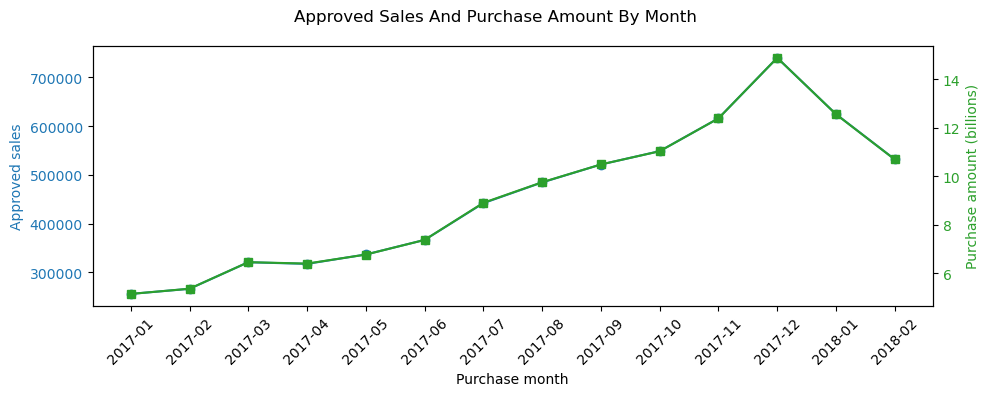

In [78]:
monthly_behavior_pd = (
    gold_monthly_behavior_with_change
    .select("purchase_month_display", "n_sales", "purchase_total")
    .orderBy("purchase_month_display")
    .toPandas()
)

fig, ax_sales = plt.subplots(figsize=(10, 4))
ax_sales.plot(monthly_behavior_pd["purchase_month_display"], monthly_behavior_pd["n_sales"], marker="o", color="#1f77b4", label="Sales count")
ax_sales.set_xlabel("Purchase month")
ax_sales.set_ylabel("Approved sales", color="#1f77b4")
ax_sales.tick_params(axis="y", labelcolor="#1f77b4")
ax_sales.tick_params(axis="x", rotation=45)

ax_revenue = ax_sales.twinx()
ax_revenue.plot(monthly_behavior_pd["purchase_month_display"], monthly_behavior_pd["purchase_total"] / 1_000_000_000, marker="s", color="#2ca02c", label="Purchase amount")
ax_revenue.set_ylabel("Purchase amount (billions)", color="#2ca02c")
ax_revenue.tick_params(axis="y", labelcolor="#2ca02c")

fig.suptitle("Approved Sales And Purchase Amount By Month")
fig.tight_layout()
plt.show()


In [79]:
gold_hourly_behavior = (
    gold_sales
    .groupBy("purchase_hour", "purchase_hour_label")
    .agg(
        F.count("*").alias("n_sales"),
        F.sum("purchase_amount").alias("purchase_total"),
    )
    .orderBy(F.desc("n_sales"), F.desc("purchase_total"))
)

format_for_display(gold_hourly_behavior, money_columns=["purchase_total"], integer_columns=["n_sales"]).limit(DISPLAY_ROWS)


purchase_hour,purchase_hour_label,n_sales,purchase_total
13,1300,"471,312","9,467,183,620.39"
12,1200,"464,985","9,346,508,321.84"
15,1500,"450,880","9,057,952,355.98"
14,1400,"448,415","9,018,322,269.88"
16,1600,"447,825","9,000,711,477.31"
17,1700,"447,367","8,996,462,121.45"
18,1800,"434,780","8,746,766,458.17"
19,1900,"404,614","8,128,696,156.69"
11,1100,"399,563","8,039,465,391.98"
20,2000,"362,349","7,292,939,828.22"


In [80]:
GROSS_PROFIT_RATE = 0.25
MONTHLY_DEFAULT_RATE = 0.229

installment_base = gold_sales.filter(F.col("installments").isNotNull() & (F.col("installments") > 0))

gold_installment_analysis = (
    installment_base
    .groupBy("installments")
    .agg(
        F.count("*").alias("n_sales"),
        F.sum("purchase_amount").alias("purchase_total"),
        F.avg("purchase_amount").alias("average_amount"),
    )
    .withColumn("gross_profit", F.col("purchase_total") * F.lit(GROSS_PROFIT_RATE))
    .withColumn("default_exposure_months", F.ceil(F.col("installments") / F.lit(2)))
    .withColumn("default_probability", F.lit(1) - F.pow(F.lit(1 - MONTHLY_DEFAULT_RATE), F.col("default_exposure_months")))
    .withColumn("unpaid_sales_at_default", F.col("purchase_total") * F.lit(0.5))
    .withColumn("expected_default_loss", F.col("unpaid_sales_at_default") * F.col("default_probability"))
    .withColumn("expected_profit_after_default", F.col("gross_profit") - F.col("expected_default_loss"))
    .orderBy("installments")
)

format_for_display(
    gold_installment_analysis,
    money_columns=["purchase_total", "average_amount", "gross_profit", "unpaid_sales_at_default", "expected_default_loss", "expected_profit_after_default"],
    integer_columns=["n_sales"],
    percent_columns=["default_probability"],
).limit(DISPLAY_ROWS)


installments,n_sales,purchase_total,average_amount,gross_profit,default_exposure_months,default_probability,unpaid_sales_at_default,expected_default_loss,expected_profit_after_default
1,"2,594,650","52,152,553,102.47","20,100.03","13,038,138,275.62",1,22.90%,"26,076,276,551.23","5,971,467,330.23","7,066,670,945.38"
2,"139,780","2,806,070,484.91","20,074.91","701,517,621.23",1,22.90%,"1,403,035,242.45","321,295,070.52","380,222,550.71"
3,"111,105","2,236,824,387.70","20,132.53","559,206,096.92",2,40.56%,"1,118,412,193.85","453,582,130.93","105,623,966.00"
4,"35,178","706,511,658.71","20,083.91","176,627,914.68",2,40.56%,"353,255,829.35","143,266,080.90","33,361,833.78"
5,"22,652","454,949,193.74","20,084.28","113,737,298.44",3,54.17%,"227,474,596.87","123,219,801.98","-9,482,503.54"
6,"24,705","498,425,959.10","20,175.10","124,606,489.78",3,54.17%,"249,212,979.55","134,995,179.30","-10,388,689.52"
7,"1,828","36,462,867.96","19,946.86","9,115,716.99",4,64.66%,"18,231,433.98","11,789,172.60","-2,673,455.61"
8,"3,377","68,376,053.83","20,247.57","17,094,013.46",4,64.66%,"34,188,026.91","22,107,342.22","-5,013,328.76"
9,854,"16,894,182.21","19,782.41","4,223,545.55",5,72.76%,"8,447,091.11","6,145,760.21","-1,922,214.65"
10,"19,920","400,942,516.82","20,127.64","100,235,629.21",5,72.76%,"200,471,258.41","145,854,740.67","-45,619,111.46"


## Final Recommendations

Based on the approved historical transactions after quarantining ambiguous duplicate merchant IDs, I would advise the new merchant as follows:

- **Cities:** Focus first on transaction city `69`, then expand into `1`, `19`, `158`, and `17`. City `69` is still the clear leader with `872,267` approved sales, `99,106` customers, and `17.52B` in purchase amount. The next strongest city, `1`, has `492,216` approved sales and `9.90B` in purchase amount.
- **Categories:** Prioritize categories `A` and `B`. Category `A` leads with `3,410,771` approved sales and `68.56B` purchase amount, while `B` is also very large with `2,555,120` approved sales and `51.36B` purchase amount. Category `C` has similar average ticket size but much lower volume (`367,678` sales and `7.39B`), so I would treat it as a secondary opportunity.
- **Months:** Expect a strong ramp through the second half of the year. The observed peak is `201712` / December 2017 with `740,332` approved sales and `14.88B` purchase amount. November and December look especially important; January and February 2018 decline after the peak, which may indicate seasonality or simply the edge of the sample window. The month graph above backs this pattern visually.
- **Hours:** Recommend opening no later than `10:00` and staying open through at least `21:00`, with core staffing from `12:00` to `19:00`. The top sales hours are `13:00`, `12:00`, `15:00`, `14:00`, `16:00`, `17:00`, and `18:00`, so demand is concentrated from midday through early evening.
- **Installments:** Accept short installment plans, but limit long plans. Under the PDF assumptions, 1-4 installments still have positive expected profit after default loss. Starting at 5 installments, expected profit turns negative, so I would recommend allowing installments only up to 4 unless the merchant has additional risk controls.
- **Denied transactions caveat:** Denied transactions are excluded from sales metrics because they are not completed sales. They are still worth monitoring separately: `8.64%` of transaction attempts were denied, which may represent payment friction, fraud/risk filtering, or unconverted demand.
- **Duplicate merchant caveat:** I excluded `41` duplicated merchant IDs from the analysis instead of selecting a canonical merchant profile. That quarantines `299,844` transaction rows (`4.12%`) and avoids trusting conflicting merchant attributes.
- **Location/category relationship:** Cramer's V is about `0.168`, which suggests a weak-to-moderate practical relationship between transaction city and category. I would use city demand and category demand as related but still separate planning signals.

Important caveat: many merchant profile locations are `-1`, so Q5 city advice is based on transaction city rather than merchant profile city.
